# Tutorial 02 — Kinking and growth of an inclined crack

**What you will learn**

- how the propagation loop works: solve, extract $K_I, K_{II}$ at every tip, choose a direction,
  extend, repeat;
- how the maximum tangential stress (MTS) criterion predicts the kink angle;
- how to record and verify a growth run with the same input → notebook → output contract as the
  full Brazilian-disk simulations.

**The problem.** A straight crack of length $2a$ at $\beta = 45°$ sits in an infinite plate under
uniaxial tension $\sigma_{yy}$. It is loaded in mixed mode, $K_I = K_{II} = \tfrac12\sigma\sqrt{\pi a}$.
Each tip kinks by the MTS angle

$$\theta = 2\arctan\frac{K_I - \sqrt{K_I^2 + 8K_{II}^2}}{4K_{II}},$$

which is $-53.13°$ for $K_I = K_{II}$. The crack then turns until it runs perpendicular to the
load, where $K_{II} \to 0$ (pure mode I).

**The growth rule.** A tip grows while $K_{\rm eff} = \sqrt{K_I^2 + K_{II}^2} > K_c$. At each step
every tip is evaluated on the *same* equilibrium solution, then all tips advance together by
$\Delta a = f\,L$, where $L$ is the current crack length.

**Runtime.** About one minute with the Python engine.

## 1. Pick the case workbook

All parameters live in `input/kinking_growth.xlsx`. Put a `Symbol` in `OVERRIDES` to change it for this run only.

In [1]:
CASE_XLSX = "input/kinking_growth.xlsx"
OVERRIDES = {}              # e.g. {"beta_deg": 30, "n_steps": 15}
SHOW_PLOTS = True
QUIET = True                # hide solver log lines

## 2. Setup: paths, workbook, engine

In [2]:
import sys, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

TUT_DIR = Path.cwd()                          # this tutorial's folder
sys.path.insert(0, str(TUT_DIR.parent))       # tutorials/ -> tutorial_utils
import tutorial_utils as tu
tu.setup_paths()                              # vcem/ -> fracture_utils

from fracture_utils.Usolver.network import CrackNetworkV4
from fracture_utils.Usolver.material import Material, AppliedStress

# Read the workbook, apply this run's overrides, and flatten to {symbol: value}
case_path = (TUT_DIR / CASE_XLSX).resolve()
tables = tu.read_workbook(case_path)
overrides_applied = tu.apply_overrides(tables, OVERRIDES)
P = tu.flat_values(tables)

ENGINE, engine_note = tu.resolve_engine(P["engine"])
print(f"case     : {case_path.name}  (sha256 {tu.sha256(case_path)[:12]})")
print(f"sheets   : {', '.join(tables)}")
print(f"overrides: {overrides_applied or 'none'}")
print(f"engine   : {ENGINE}  — {engine_note}")

case     : kinking_growth.xlsx  (sha256 a5b6e8267fcd)
sheets   : Material, Geometry, Loading, Propagation, Solver, Verification, Output
overrides: none
engine   : python  — python engine requested


## 3. Build the model

Next to the material, load and initial crack, the propagation loop needs four pieces:

| Object | Role |
|---|---|
| `CandidateEvaluator` | solves the network and fits $K_I, K_{II}$ at a tip |
| `MaximumHoopStressLaw` | turns $(K_I, K_{II})$ into a kink angle |
| `ConstantToughness` | supplies $K_c$ |
| `CrackPropagator` | runs one growth increment for all tips |

In [3]:
plane_stress = str(P["plane"]).lower().startswith("stress")
material = Material(E=float(P["E"]), nu=float(P["nu"]), plane_stress=plane_stress)
applied = AppliedStress(sigma_xx=float(P["sigma_xx"]), sigma_yy=float(P["sigma_yy"]),
                        sigma_xy=float(P["sigma_xy"]))

E, nu = float(P["E"]), float(P["nu"])
E_prime = E if plane_stress else E / (1.0 - nu**2)       # effective modulus
a = float(P["a"])
sig = np.array([[P["sigma_xx"], P["sigma_xy"]], [P["sigma_xy"], P["sigma_yy"]]], float)
K0 = float(P["sigma_yy"]) * np.sqrt(np.pi * a)           # reference SIF, sigma_yy * sqrt(pi a)


def straight_crack(beta_deg: float, half_length: float = a) -> CrackNetworkV4:
    """One straight crack through the origin at angle beta from the x-axis."""
    b = np.radians(beta_deg)
    c, s = np.cos(b), np.sin(b)
    V = np.array([[0, -half_length * c, -half_length * s],
                  [1, +half_length * c, +half_length * s]], float)
    return CrackNetworkV4.from_vertices_connectivity(
        vertices=V, connectivity=np.array([[0, 1]]), Nv_max=3, validate=True)


def exact_K(beta_deg: float, half_length: float = a):
    """Griffith crack in an infinite plate: K_I = sigma_nn sqrt(pi a), K_II = sigma_nt sqrt(pi a)."""
    b = np.radians(beta_deg)
    t = np.array([np.cos(b), np.sin(b)])      # crack tangent
    n = np.array([-np.sin(b), np.cos(b)])     # crack normal
    root = np.sqrt(np.pi * half_length)
    return float(n @ sig @ n) * root, float(t @ sig @ n) * root


print(f"E' = {E_prime/1e9:.1f} GPa,  a = {a*1e3:.2f} mm,  K0 = {K0/1e6:.3f} MPa*sqrt(m)")


from fracture_utils.Upropagation.config import PropagationConfig
from fracture_utils.Upropagation.evaluate import CandidateEvaluator
from fracture_utils.Upropagation.propagator import CrackPropagator
from fracture_utils.Upropagation.direction import MaximumHoopStressLaw
from fracture_utils.Upropagation.toughness import ConstantToughness

SOLVER_KW = dict(n_crack_elements=int(P["n_crack_elements"]), crack_mode=P["crack_mode"],
                 parametrization=P["parametrization"], engine=ENGINE)
FIT_KW = dict(rmax_frac=float(P["rmax_frac"]), min_pts=int(P["min_pts"]), two_term=bool(P["two_term"]))

law = MaximumHoopStressLaw(kii_noise_ratio=float(P["kii_noise_ratio"]))
evaluator = CandidateEvaluator(material=material, applied=applied, solver_kwargs=SOLVER_KW,
                               direction_law=law, **FIT_KW)
prop_cfg = PropagationConfig(step_mode="fixed_step", f_fixed=float(P["f_fixed"]))

net0 = straight_crack(float(P["beta_deg"]))
propagator = CrackPropagator(cfg=prop_cfg, evaluator=evaluator,
                             toughness=ConstantToughness(float(P["Kc"])), direction_law=law,
                             max_kink_deg=float(P["max_kink_deg"]),
                             initial_vertex_ids=[v.id for v in net0.vertices])


def mts_angle(KI, KII):
    """Closed-form MTS kink angle (rad)."""
    if abs(KII) < 1e-12 * max(abs(KI), 1.0):
        return 0.0
    return 2.0 * np.arctan((KI - np.sqrt(KI**2 + 8 * KII**2)) / (4 * KII))


KI0, KII0 = exact_K(float(P["beta_deg"]))
theta_exact = np.degrees(mts_angle(KI0, KII0))
print(f"exact initial SIFs: K_I = {KI0/1e6:.3f}, K_II = {KII0/1e6:.3f} MPa*sqrt(m)"
      f"  ->  MTS kink angle {theta_exact:.2f} deg")

E' = 219.8 GPa,  a = 5.00 mm,  K0 = 12.533 MPa*sqrt(m)
exact initial SIFs: K_I = 6.267, K_II = 6.267 MPa*sqrt(m)  ->  MTS kink angle -53.13 deg


## 4. Growth loop

Each call to `grow_one_increment` returns the new network and one report per tip. The loop stops
after `n_steps`, when no tip is above toughness, or when the crack exceeds `L_limit_mm`.

In [4]:
def tip_positions(net):
    """Map 'left' / 'right' -> xy of the two degree-1 vertices."""
    tips = [v for v in net.vertices if len(v.edges) == 1]
    tips.sort(key=lambda v: v.x)
    return {"left": np.array([tips[0].x, tips[0].y]), "right": np.array([tips[-1].x, tips[-1].y])}


def crack_length(net):
    xy = {v.id: np.array([v.x, v.y]) for v in net.vertices}
    return float(sum(np.linalg.norm(xy[e.v1] - xy[e.v0]) for e in net.edges))


net = net0
paths = {k: [p] for k, p in tip_positions(net).items()}
steps, stop_reason = [], "n_steps reached"
t0 = time.perf_counter()
for k in range(int(P["n_steps"])):
    pos = tip_positions(net)
    with tu.quiet(QUIET):
        result = propagator.grow_one_increment(net)
    for rep in result.reports:
        side = "right" if rep.which == "end" else "left"
        steps.append(dict(step=k + 1, tip=side, x_m=float(pos[side][0]), y_m=float(pos[side][1]),
                          KI=float(rep.KI), KII=float(rep.KII), Keff=float(rep.keff),
                          theta_deg=float(np.degrees(rep.theta)), delta_a_m=float(rep.delta_a),
                          grew=bool(rep.grew), reason=rep.reason or "", L_before_m=crack_length(net)))
    net = result.network_new
    for side, p in tip_positions(net).items():
        paths[side].append(p)
    r = [s for s in steps if s["step"] == k + 1 and s["tip"] == "right"][0]
    print(f"step {k+1:2d}: K_I = {r['KI']/1e6:6.2f}  K_II = {r['KII']/1e6:6.2f} MPa*sqrt(m)  "
          f"theta = {r['theta_deg']:7.2f} deg  L = {crack_length(net)*1e3:6.2f} mm")
    if not any(rep.grew for rep in result.reports):
        stop_reason = "all tips below toughness"; break
    if crack_length(net) * 1e3 > float(P["L_limit_mm"]):
        stop_reason = "length limit reached"; break
t_grow = time.perf_counter() - t0
print(f"\nstopped: {stop_reason}  ({len(steps)//2} steps, {t_grow:.1f} s)")

step  1: K_I =   6.45  K_II =   6.45 MPa*sqrt(m)  theta =  -53.13 deg  L =  12.00 mm


step  2: K_I =  13.57  K_II =   0.00 MPa*sqrt(m)  theta =    0.00 deg  L =  14.40 mm


step  3: K_I =  14.92  K_II =  -0.24 MPa*sqrt(m)  theta =    0.00 deg  L =  17.28 mm


step  4: K_I =  16.53  K_II =  -0.61 MPa*sqrt(m)  theta =    0.00 deg  L =  20.74 mm


step  5: K_I =  18.52  K_II =  -0.99 MPa*sqrt(m)  theta =    6.08 deg  L =  24.88 mm


step  6: K_I =  20.52  K_II =   0.16 MPa*sqrt(m)  theta =    0.00 deg  L =  29.86 mm

stopped: n_steps reached  (6 steps, 43.9 s)


## 5. Check the physics

- The first kink angle should match the MTS angle computed from the exact initial SIFs.
- By the last step the crack should run in mode I, so $|K_{II}|/K_I$ should be small.
- The problem is point-symmetric about the origin, so the two tips must mirror each other exactly.
- As the crack turns horizontal, $K_I$ approaches $\sigma\sqrt{\pi c}$, where $c$ is the half-width of
  the crack's projection on the $x$-axis. This is a guide, not an exact result.

**Watch the K_II column.** After the first kink the crack should run in pure mode I. The computed
$K_{II}$ instead drifts by one to two percent of $K_I$ with every new segment. This is a discretization
error of the kinked path, not physics. Once $|K_{II}|/(|K_I|+|K_{II}|)$ passes the noise threshold
(`kii_noise_ratio`, 5 %), MTS applies a small corrective kink. Both tips make the same correction,
and $K_{II}$ returns to near zero. That is the MTS law's self-correcting behaviour at work.

In [5]:
right = [s for s in steps if s["tip"] == "right"]
left = [s for s in steps if s["tip"] == "left"]
theta_1 = right[0]["theta_deg"]
err_theta = abs(abs(theta_1) - abs(theta_exact))
KII_ratio = abs(right[-1]["KII"]) / abs(right[-1]["KI"])
PL, PR = np.array(paths["left"]), np.array(paths["right"])
sym = float(np.max(np.abs(PL + PR)) / a)

for s in right:
    c_half = abs(s["x_m"])                  # right tip x ~ projected half-width (symmetric crack)
    s["KI_projected"] = float(P["sigma_yy"]) * np.sqrt(np.pi * c_half)

print(f"first kink angle   : {theta_1:.2f} deg   (MTS {theta_exact:.2f} deg, diff {err_theta:.3f})")
print(f"final |K_II| / K_I : {KII_ratio:.3%}")
print(f"symmetry residual  : {sym:.2e} x a")

first kink angle   : -53.13 deg   (MTS -53.13 deg, diff 0.000)
final |K_II| / K_I : 0.775%
symmetry residual  : 1.06e-08 x a


## 6. Output directory and plots

run directory: output\20260929_180344_kinking_growth_1d7539c8


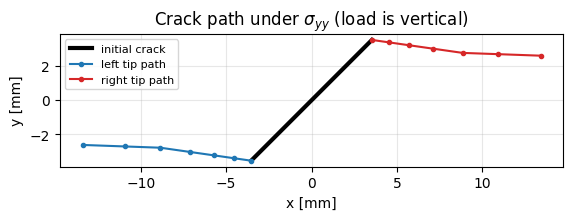

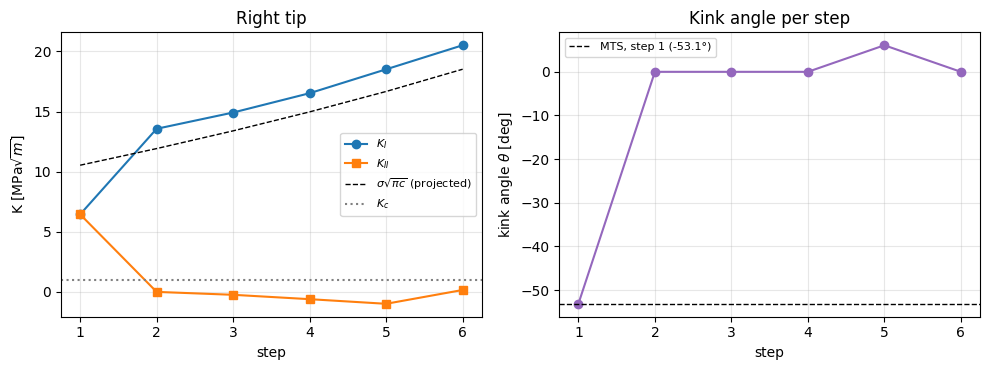

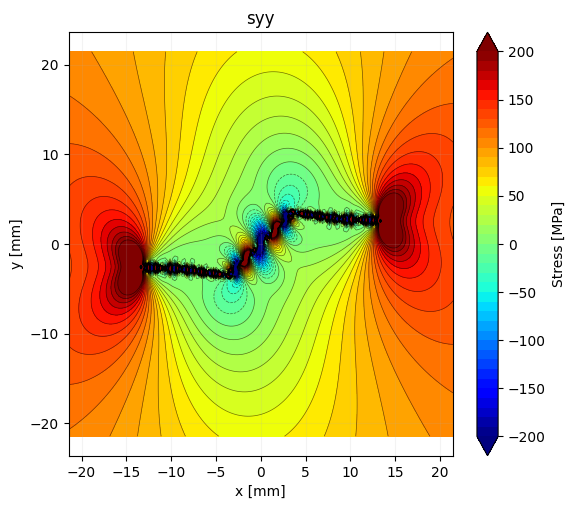

In [6]:
run_dir, run_label = tu.make_run_dir(TUT_DIR, P["label"])
plots = run_dir / "plots"
dpi = int(P["dpi"])
print("run directory:", run_dir.relative_to(TUT_DIR))

# Crack path
fig, ax = plt.subplots(figsize=(6.5, 4))
V0 = np.array([[v.x, v.y] for v in net0.vertices])
ax.plot(V0[:, 0] * 1e3, V0[:, 1] * 1e3, "k-", lw=3, label="initial crack")
for side, col in (("left", "tab:blue"), ("right", "tab:red")):
    p = np.array(paths[side]) * 1e3
    ax.plot(p[:, 0], p[:, 1], "o-", color=col, ms=3, label=f"{side} tip path")
ax.set(xlabel="x [mm]", ylabel="y [mm]", title=r"Crack path under $\sigma_{yy}$ (load is vertical)")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.savefig(plots / "crack_path.png", dpi=dpi, bbox_inches="tight")

# SIFs and kink angle along the growth
st = np.array([s["step"] for s in right])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))
ax1.plot(st, [s["KI"] / 1e6 for s in right], "o-", label=r"$K_I$")
ax1.plot(st, [s["KII"] / 1e6 for s in right], "s-", label=r"$K_{II}$")
ax1.plot(st, [s["KI_projected"] / 1e6 for s in right], "k--", lw=1, label=r"$\sigma\sqrt{\pi c}$ (projected)")
ax1.axhline(float(P["Kc"]) / 1e6, color="gray", ls=":", label=r"$K_c$")
ax1.set(xlabel="step", ylabel=r"K [MPa$\sqrt{m}$]", title="Right tip"); ax1.grid(alpha=0.3); ax1.legend(fontsize=8)
ax2.plot(st, [s["theta_deg"] for s in right], "o-", color="tab:purple")
ax2.axhline(theta_exact, color="k", ls="--", lw=1, label=f"MTS, step 1 ({theta_exact:.1f}°)")
ax2.set(xlabel="step", ylabel=r"kink angle $\theta$ [deg]", title="Kink angle per step")
ax2.grid(alpha=0.3); ax2.legend(fontsize=8)
fig.tight_layout()
fig.savefig(plots / "SIF_and_kink_vs_step.png", dpi=dpi, bbox_inches="tight")

# Stress field around the final crack
from fracture_utils.Usolver.parametrization import DCENetworkStaticV4
from fracture_utils.Uprocessor.results import DCEResultsNetworkV4
from fracture_utils.Uplotter.core import DCEPlotterV4
from fracture_utils.Uplotter.opts import StressPlotOptsV4

calc_f = DCENetworkStaticV4(material, net, applied)
with tu.quiet(QUIET):
    res_f = DCEResultsNetworkV4(calc_f, calc_f.solve(**SOLVER_KW))
DCEPlotterV4(res_f, out_dir=plots).plot_stress_components_global(
    opts=StressPlotOptsV4(extent_factor=float(P["stress_extent"]), n_grid=int(P["stress_n_grid"]),
                          add_remote=True, n_bands=40, vmax_factor=2.0),
    components=("syy",), show=SHOW_PLOTS)

if SHOW_PLOTS:
    plt.show()
plt.close("all")

## 7. Results, diagnostics and provenance

- `growth_steps.csv` — one row per tip per step: position, $K_I$, $K_{II}$, $K_{\rm eff}$, kink angle, $\Delta a$;
- `crack_path.csv` — the tip trajectories;
- `summary.csv`, `diagnostics.txt`, `provenance.md` — as in Tutorial 01.

In [7]:
tu.write_csv(run_dir / "growth_steps.csv", steps)
tu.write_csv(run_dir / "crack_path.csv",
             [dict(point=i, tip=side, x_m=float(p[0]), y_m=float(p[1]))
              for side in ("left", "right") for i, p in enumerate(paths[side])])

checks = [
    ("first kink angle vs MTS", err_theta, float(P["tol_theta_deg"]), "deg"),
    ("final |K_II| / K_I", KII_ratio, float(P["tol_KII_ratio"]), "-"),
    ("path point-symmetry residual", sym, float(P["tol_symmetry"]), "x a"),
]
ok = tu.write_diagnostics(run_dir / "diagnostics.txt", run_label, checks)

tu.write_csv(run_dir / "summary.csv", [dict(
    run=run_label, engine=ENGINE, beta_deg=float(P["beta_deg"]), n_steps=len(right),
    L_final_mm=crack_length(net) * 1e3, theta_1_deg=theta_1, theta_MTS_deg=theta_exact,
    KI_final=right[-1]["KI"], KII_final=right[-1]["KII"], stop_reason=stop_reason,
    status="PASS" if ok else "FAIL")])

tu.write_provenance(
    run_dir, run_label, title="VCEM tutorial 02 (crack kinking and growth)", tables=tables,
    overrides=overrides_applied,
    user_selections=dict(tutorial="02_crack_kinking_growth", case_workbook=tu.repo_relative(case_path),
                         case_sha256=tu.sha256(case_path), engine_requested=P["engine"],
                         engine_used=ENGINE, engine_note=engine_note, domain="infinite plate",
                         direction_law="MaximumHoopStressLaw", toughness="ConstantToughness"),
    solver_config={**{f"solve.{k}": v for k, v in SOLVER_KW.items()},
                   **{f"sif_fit.{k}": v for k, v in FIT_KW.items()},
                   "propagation.step_mode": prop_cfg.step_mode, "propagation.f_fixed": prop_cfg.f_fixed,
                   "propagation.simultaneous_tip_growth": prop_cfg.simultaneous_tip_growth,
                   "propagation.max_kink_deg": float(P["max_kink_deg"]),
                   "propagation.kii_noise_ratio": float(P["kii_noise_ratio"])},
    run_stats=dict(wall_clock_growth_s=t_grow, n_steps=len(right), stop_reason=stop_reason,
                   L_final_mm=crack_length(net) * 1e3, run_status="completed",
                   diagnostics="PASS" if ok else "FAIL"))

print((run_dir / "diagnostics.txt").read_text())
print("files:", sorted(p.name for p in run_dir.iterdir()))

Diagnostics â€” 20260929_180344_kinking_growth_1d7539c8

[PASS] first kink angle vs MTS: 7.105e-15 deg (tolerance 1 deg)
[PASS] final |K_II| / K_I: 0.007749 - (tolerance 0.05 -)
[PASS] path point-symmetry residual: 1.064e-08 x a (tolerance 1e-06 x a)

Overall: PASS

files: ['crack_path.csv', 'diagnostics.txt', 'growth_steps.csv', 'plots', 'provenance.md', 'summary.csv']


## 8. Try this

1. **Other angles.** Set `{"beta_deg": 30}` or `{"beta_deg": 60}`. The first kink follows the MTS
   angle, and the path always turns perpendicular to the load.
2. **Tough material.** Set `{"Kc": 15e6}`. With $K_{\rm eff} < K_c$ the crack does not grow at all.
3. **Kink clamp.** Set `{"max_kink_deg": 10}`. After the first kink, the path is smoothed.
4. **Step size.** Halve `f_fixed` and double `n_steps`. Is the path converged?
5. **Crack mode.** Set `{"crack_mode": "full"}`. The $K_{II}$ drift is larger in the dipolar mode,
   and the corrective kinks come sooner and are no longer symmetric.

**Next.** The same loop, with the plate replaced by a finite disk solved by the BEM, drives the
full Brazilian-disk simulations in `vcem/notebooks/SimulationsCpp.ipynb`.